# Notebook 04 — Visual Feature Extraction

**Duration:** ~25 minutes

In notebook 03 you extracted information from legislative text. In this notebook you apply the **exact same pipeline** to images.

The dataset is a curated selection of **World War I recruitment and propaganda posters** from **Archives New Zealand**, accessed via Wikimedia Commons. All images are in the public domain under New Zealand's NZGOAL framework.

You will:

1. Send an image to a vision-capable LLM and extract structured features as JSON
2. Validate the image keywords against parliamentary committee domains using Jaccard similarity — the same method the published study used to check its text analysis
3. Compare the model's output against archival metadata written by human archivists
4. Test yourself: read a PDF of the Impounding Act 1955 two ways — as extracted text and as page images — and compare the answers

The point: the data type changed. The methodology did not.

## Setup

Run this cell first. It loads your base URL and API key from the `.env` file you set up in notebook 01.

Note: this notebook sends the model **images** as well as text. Our model can read both, so we use the same `MODEL` as in every other notebook.

In [5]:
# ============================================================
# SETUP CELL — Run this once at the start of every notebook
# ============================================================

import os, json, base64, requests, io
from openai import OpenAI, AuthenticationError, APIConnectionError
from lxml import etree
from PIL import Image
from IPython.display import Image as IPImage, display

# Load your base URL and API key.
# In VS Code they come from the .env file (set up in notebook 01).
# In Google Colab there is no .env file, so the cell asks you to paste them in.
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from getpass import getpass
    os.environ["LLM_BASE_URL"] = input("Paste your base URL: ").strip()
    os.environ["LLM_API_KEY"] = getpass("Paste your API key: ").strip()
else:
    from dotenv import load_dotenv
    load_dotenv(override=True)

if not os.getenv("LLM_BASE_URL") or not os.getenv("LLM_API_KEY"):
    if IN_COLAB:
        raise RuntimeError("Base URL or API key is empty. Run this cell again and paste both values.")
    raise RuntimeError("Could not find LLM_BASE_URL or LLM_API_KEY. Check your .env file (see notebook 01).")

client = OpenAI(base_url=os.environ["LLM_BASE_URL"], api_key=os.environ["LLM_API_KEY"])

# Ask the machine which model it serves. Each machine serves one model, and
# not every machine serves the same one, so we look the name up.
# The model reads both text and images.
try:
    MODEL = client.models.list().data[0].id
except AuthenticationError:
    raise RuntimeError("The machine rejected your API key. Check it, then run this cell again.") from None
except APIConnectionError:
    raise RuntimeError(
        "Could not reach the machine. Check your base URL. "
        "In VS Code, also check that you are on the university VPN."
    ) from None

# To choose a model yourself, remove the # at the start of the next line
# and put the model's name between the quote marks.
# MODEL = "nvidia/Nemotron-3-Nano-Omni-30B-A3B-Reasoning-NVFP4"

# Turn off the model's "thinking" step. Answers come back several times faster,
# which matters when many people share one machine.
NO_THINKING = {"chat_template_kwargs": {"enable_thinking": False}}

print(f"Using model {MODEL}.")
print("Setup complete.")

Using model nvidia/Nemotron-3-Nano-Omni-30B-A3B-Reasoning-NVFP4.
Setup complete.


## Browse the image corpus

We fetch images from the **Wikimedia Commons API** — a public repository of freely licensed media. Archives New Zealand has contributed thousands of historical images to the collection.

The curated corpus for this workshop contains four WWI-era posters — recruitment appeals, propaganda, and government notices. Each one contains visible text, political messaging, and visual symbols designed to persuade. Run the cell below to see all four. Then you will pick your favourite to analyse.

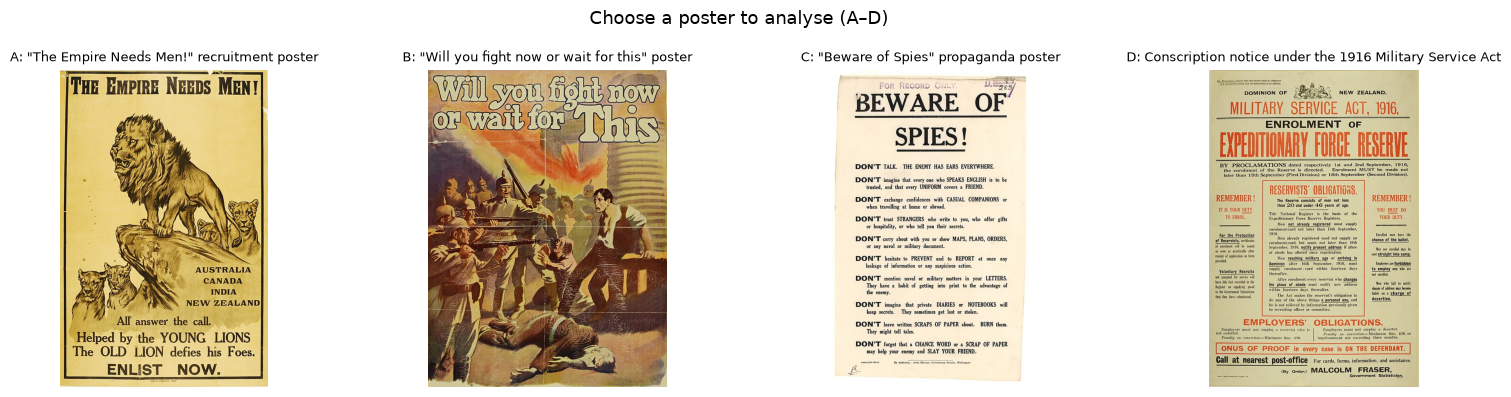

In [6]:
# Curated image corpus — four WWI posters from Archives New Zealand
IMAGE_CORPUS = {
    "A": {
        "title": "File:\"The Empire Needs Men!\" Recruitment poster for World War I (14842191503).jpg",
        "label": "\"The Empire Needs Men!\" recruitment poster",
    },
    "B": {
        "title": "File:\"Will you fight now or wait for this\" recruitment poster (14831036372).jpg",
        "label": "\"Will you fight now or wait for this\" poster",
    },
    "C": {
        "title": "File:'Beware of Spies' World War I propaganda poster (14603583360).jpg",
        "label": "\"Beware of Spies\" propaganda poster",
    },
    "D": {
        "title": "File:Conscription Poster (14644744689).jpg",
        "label": "Conscription notice under the 1916 Military Service Act",
    },
}

api_url = "https://commons.wikimedia.org/w/api.php"
headers = {
    "User-Agent": "UoA-eResearch-LLM-Workshop/1.0 (researchdata@auckland.ac.nz)"
}

# Fetch thumbnails for all four images and display them as a gallery
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (key, info) in zip(axes, IMAGE_CORPUS.items()):
    params = {
        "action": "query",
        "titles": info["title"],
        "prop": "imageinfo",
        "iiprop": "url|size|extmetadata",
        "iiurlwidth": 400,
        "format": "json"
    }
    resp = requests.get(api_url, params=params, headers=headers, timeout=15)
    pages = resp.json()["query"]["pages"]
    page = list(pages.values())[0]
    img_info = page["imageinfo"][0]
    thumb = img_info.get("thumburl", img_info["url"])

    img_resp = requests.get(thumb, headers=headers, timeout=15)
    img = Image.open(io.BytesIO(img_resp.content))

    ax.imshow(img)
    ax.set_title(f"{key}: {info['label']}", fontsize=9, wrap=True)
    ax.axis("off")

plt.suptitle("Choose a poster to analyse (A–D)", fontsize=13)
plt.tight_layout()
plt.show()

You chose A: "The Empire Needs Men!" recruitment poster
Image size: 400x608 — ready for API.



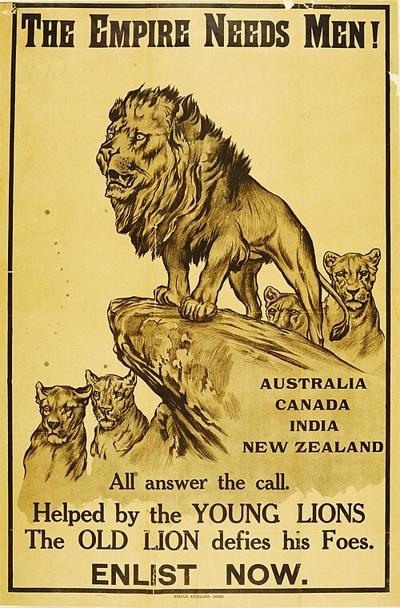

In [7]:
# ============================================================
# CHOOSE YOUR IMAGE — change the letter to A, B, C, or D
# ============================================================
CHOSEN = "A"

# Fetch the chosen image
chosen_info = IMAGE_CORPUS[CHOSEN]
image_title = chosen_info["title"]

params = {
    "action": "query",
    "titles": image_title,
    "prop": "imageinfo",
    "iiprop": "url|size|extmetadata",
    "iiurlwidth": 400,
    "format": "json"
}
api_response = requests.get(api_url, params=params, headers=headers, timeout=15)
pages = api_response.json()["query"]["pages"]
page = list(pages.values())[0]
image_info = page["imageinfo"][0]
thumb_url = image_info.get("thumburl", image_info["url"])

# Extract the archival description (used later for validation)
metadata = image_info.get("extmetadata", {})
archival_description = metadata.get("ImageDescription", {}).get("value", "No description available.")

# Download and prepare the image
img_response = requests.get(thumb_url, headers=headers, timeout=15)
img = Image.open(io.BytesIO(img_response.content))

new_width = 400
if img.width != new_width:
    ratio = new_width / img.width
    new_height = int(img.height * ratio)
    img = img.resize((new_width, new_height))
else:
    new_height = img.height

# Convert to base64 for the API call
buffer = io.BytesIO()
img.save(buffer, format="JPEG")
img_base64 = base64.b64encode(buffer.getvalue()).decode("utf-8")

# Display the chosen image
print(f"You chose {CHOSEN}: {chosen_info['label']}")
print(f"Image size: {new_width}x{new_height} — ready for API.")
print()
display(IPImage(data=buffer.getvalue(), format="jpeg"))


You should see your chosen image displayed above. Take a moment to look at it before we ask the model to analyse it.

What do you notice? What details stand out? What do you think the image is about? Hold those observations — you will compare them against what the model produces.


## Where this fits in the research workflow

> **Research context:** The published study on NZ legislative networks (Ardekani et al., 2026) worked entirely with text. But the extraction and validation logic you have been practising works on any unstructured source. Images are just another kind of unstructured data. The pipeline is identical: extract structured features, generate keywords, validate against an external reference.

In this notebook you are doing:
- **Extraction** (Step 2) — pulling structured JSON from an image instead of from XML
- **Interpretation** (Step 6) — validating image keywords against committee domains using Jaccard similarity

## Exercise a — Structured JSON extraction from an image

In notebook 03 you asked the LLM to extract Act references from text as JSON. Now you do the same thing with an image — ask the model to describe what it sees and return the results in a structured format.

The prompt asks the model to fill in these fields:
- **scene_description** — what is happening in the image
- **political_claim** — what political argument or demand is being made
- **visible_text** — any text that appears in the image
- **symbols** — visual symbols, logos, flags, or iconography
- **keywords** — 20 to 25 keywords describing the image's content (this feeds into exercise b)
- **confidence** — how confident the model is in its analysis (high / medium / low)

In notebook 03 you had to tidy up the reply yourself, because the model sometimes wrapped its JSON in extra text or code fences. This time the code uses **JSON mode**. JSON mode is a setting in the API call, `response_format={"type": "json_object"}`, that forces the model to reply with valid JSON and nothing else. The prompt still describes which fields you want — JSON mode controls the *format* of the reply, not its *content*. The model can still return valid JSON that is wrong, so you check its answers in exercises b and c.

Run the cell below.

In [8]:
vision_response = client.chat.completions.create(
    model=MODEL,
    extra_body=NO_THINKING,
    temperature=0,
    # JSON mode: the reply is guaranteed to be valid JSON
    response_format={"type": "json_object"},
    messages=[
        {
            "role": "system",
            "content": "You are a research assistant analysing historical archival images from New Zealand."
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": """Analyse this historical image from Archives New Zealand.

Extract the following features and return them as a JSON object:
{
  "scene_description": "What is happening in this image?",
  "political_claim": "What political argument or demand is being made?",
  "visible_text": "Any text visible in the image (or 'none' if not legible)",
  "symbols": "Visual symbols, logos, flags, or iconography present",
  "keywords": ["20 - 25 keywords describing the content"],
  "confidence": "high, medium, or low"
}

Return ONLY the JSON object."""
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{img_base64}"
                    }
                }
            ]
        }
    ]
)

vision_raw = vision_response.choices[0].message.content.strip()

# Parse the JSON — no clean-up needed, because JSON mode guarantees valid JSON
image_features = json.loads(vision_raw)

# Pretty-print the results
print("Extracted features:")
print("=" * 60)
for key, value in image_features.items():
    if isinstance(value, list):
        print(f"\n{key}:")
        for item in value:
            print(f"  - {item}")
    else:
        print(f"\n{key}: {value}")

Extracted features:

scene_description: A large lion stands atop a rock, with several smaller lions (labeled as 'Young Lions') surrounding it. The scene is a symbolic representation of the British Empire calling for men to enlist in World War I.

political_claim: The Empire is demanding men to enlist in the military, using the metaphor of the 'Old Lion' (Britain) defending its 'Foes' while the 'Young Lions' (Dominions) are called to help.

visible_text: THE EMPIRE NEEDS MEN! AUSTRALIA CANADA INDIA NEW ZEALAND All answer the call. Helped by the YOUNG LIONS The OLD LION defies his Foes. ENLIST NOW.

symbols:
  - Lion
  - Rock
  - Text labels for Dominions

keywords:
  - World War I
  - Recruitment
  - Empire
  - Lion symbolism
  - Australia
  - Canada
  - India
  - New Zealand
  - British Empire
  - Military Enlistment
  - Propaganda
  - Young Lions
  - Old Lion
  - Call to Action

confidence: high


Read through the results. Some questions to consider:

- Does the **scene description** match what you see?
- Did the model correctly read any **visible text** in the image, or did it guess?
- Is the **political claim** reasonable, or did the model project something that is not there?
- How would you rate your own confidence compared to the model's?

This is the same critical eye you applied to text extraction in notebook 03. The data type is different. The questions are the same.

## Exercise b — Cross-modal Jaccard validation

The published study (Ardekani et al., 2026) checked its results against New Zealand's **parliamentary select committees**. These are groups of MPs (Members of Parliament) that each look after one policy area, such as justice or social services. The authors gave each committee a list of keywords and measured how well their results matched each list. Now you do the same thing with the keywords the model extracted from the image.

The measure is called **Jaccard similarity**. It compares two lists of words. It counts the words that appear in both lists, then divides by the number of different words across the two lists combined. A score of 0 means the lists share no words. A score of 1 means they are identical. Imagine you coded 500 interview transcripts and want to know which policy area each one speaks to: Jaccard similarity gives you a quick, repeatable way to compare each transcript's keywords against each area's keywords.

The question: does the model's keyword description of a historical protest image align with any recognisable policy domain?

In [9]:
# Jaccard similarity function
def jaccard_similarity(set_a, set_b):
    """Calculate Jaccard similarity between two sets of strings."""
    a = set(w.lower() for w in set_a)
    b = set(w.lower() for w in set_b)
    intersection = a & b
    union = a | b
    if not union:
        return 0.0
    return len(intersection) / len(union)

# Parliamentary select committee keyword sets
# Includes the Foreign Affairs, Defence and Trade Committee,
# which is relevant to the wartime image corpus in this notebook.
COMMITTEE_KEYWORDS = {
    "Justice Committee": [
        "criminal", "justice", "court", "offence", "penalty",
        "prosecution", "enforcement", "police", "imprisonment",
        "tribunal", "legal", "rights", "appeal", "sentence", "conviction"
    ],
    "Finance and Expenditure Committee": [
        "financial", "revenue", "tax", "expenditure", "budget",
        "fiscal", "economic", "payment", "fund", "investment",
        "commercial", "income", "cost", "penalty", "levy"
    ],
    "Governance and Administration Committee": [
        "privacy", "information", "data", "personal", "agency",
        "public", "government", "official", "disclosure", "access",
        "transparency", "accountability", "complaint", "commissioner",
        "record"
    ],
    "Social Services and Community Committee": [
        "social", "community", "welfare", "family", "housing",
        "poverty", "employment", "education", "youth", "elderly",
        "disability", "support", "benefit", "vulnerable", "protection"
    ],
    "Foreign Affairs, Defence and Trade Committee": [
        "defence", "military", "war", "foreign", "security",
        "armed", "treaty", "trade", "intelligence", "espionage",
        "diplomacy", "veteran", "conscription", "alliance", "sovereignty"
    ]
}

print("Jaccard function and committee keywords loaded.")

Jaccard function and committee keywords loaded.


In [10]:
# Get the image keywords from the extraction
image_keywords = image_features.get("keywords", [])

print(f"Image keywords ({len(image_keywords)}):")
print(f"  {', '.join(image_keywords)}")
print()

# Compare image keywords against each committee
print("Image keywords — Jaccard similarity with each committee:")
print("=" * 60)
image_scores = {}
for committee, kws in COMMITTEE_KEYWORDS.items():
    score = jaccard_similarity(image_keywords, kws)
    image_scores[committee] = score
    bar = "█" * int(score * 40)
    print(f"  {committee:45s} {score:.3f} {bar}")

best_committee = max(image_scores, key=image_scores.get)
print(f"\nBest match: {best_committee} ({image_scores[best_committee]:.3f})")

Image keywords (14):
  World War I, Recruitment, Empire, Lion symbolism, Australia, Canada, India, New Zealand, British Empire, Military Enlistment, Propaganda, Young Lions, Old Lion, Call to Action

Image keywords — Jaccard similarity with each committee:
  Justice Committee                             0.000 
  Finance and Expenditure Committee             0.000 
  Governance and Administration Committee       0.000 
  Social Services and Community Committee       0.000 
  Foreign Affairs, Defence and Trade Committee  0.000 

Best match: Justice Committee (0.000)


### Does the match make sense?

Think about the poster you chose and which committee scored highest:
- **"The Empire Needs Men!"** (A) is a recruitment appeal using imperial imagery — expect Justice or Governance
- **"Will you fight now or wait for this"** (B) uses fear and threat — expect Justice (enforcement, penalty) or Social Services
- **"Beware of Spies"** (C) is about surveillance and vigilance — expect Governance and Administration (information, disclosure, transparency)
- **Conscription notice** (D) is a legal notice under the Military Service Act — expect Justice (legal, enforcement, prosecution)

Think about:
- Does the model's best-match committee align with what you see in the poster?
- If there is a discrepancy, is it because the model misread the image, or because the committee keywords do not capture wartime topics well?
- Would a human researcher categorise this poster the same way?

### Compare against archival metadata

The Wikimedia Commons API provides the original archival description for each image. This is metadata written by human archivists at Archives New Zealand — an independent reference we can compare against.

This is the same logic as the human spot-check from notebook 03: compare what the model produced against a trusted external source.

In [11]:
# Show the archival metadata alongside the model's description
print("ARCHIVAL METADATA (written by human archivists):")
print("=" * 60)
print(archival_description)
print()
print("MODEL'S DESCRIPTION:")
print("=" * 60)
print(image_features.get("scene_description", "(not available)"))
print()
print("MODEL'S POLITICAL CLAIM:")
print("=" * 60)
print(image_features.get("political_claim", "(not available)"))
print()
print("Questions to consider:")
print("  1. Does the model's description match the archival record?")
print("  2. Did the model add details not in the metadata (hallucination)?")
print("  3. Did the metadata contain information the model missed?")

ARCHIVAL METADATA (written by human archivists):
<p>New Zealand Expeditionary Force recruitment poster from Archives New Zealand's Army Department files.
</p>
Archives New Zealand Reference: AD1 9/169/2/1 R22444228

MODEL'S DESCRIPTION:
A large lion stands atop a rock, with several smaller lions (labeled as 'Young Lions') surrounding it. The scene is a symbolic representation of the British Empire calling for men to enlist in World War I.

MODEL'S POLITICAL CLAIM:
The Empire is demanding men to enlist in the military, using the metaphor of the 'Old Lion' (Britain) defending its 'Foes' while the 'Young Lions' (Dominions) are called to help.

Questions to consider:
  1. Does the model's description match the archival record?
  2. Did the model add details not in the metadata (hallucination)?
  3. Did the metadata contain information the model missed?


> "You used the same extraction and validation pipeline on an image that you used on text. The data type changed. The methodology did not."

## Test yourself — Read the Act from a PDF

In notebook 02 you asked the model for the maximum fine under the Impounding Act 1955 for leaving a gate open on a public road. It answered from memory, and it was almost certainly wrong. This time the model gets to read the Act itself.

Most documents researchers work with do not arrive as tidy XML. They arrive as **PDFs** (Portable Document Format files): reports, submissions, meeting minutes, scanned archive files. Imagine you have 200 public submissions on a council bylaw, all saved as PDFs. Before an LLM can help you analyse them, you need to get each PDF's content into the model.

There are two ways to do that:

1. **Extract the text.** Pull the words out of the PDF and send them as plain text, as you did with the XML in notebook 03.
2. **Send pictures of the pages.** Turn each page into an image and send it to the model, as you did with the poster above.

In this test you try both. You ask the same question each way, then compare the answers.

The Act is saved in the repository as `data/impounding-act-1955.pdf`. It is the official copy from the New Zealand Legislation website. The whole Act is 32 pages long. The section you need starts at the bottom of page 25 and finishes on page 26, so we send only those two pages. Sending less keeps the shared machine fast.

### Step 1 — Load the PDF

We open the PDF with a Python package called **PyMuPDF**. (A **package** is a bundle of ready-made code that someone else has written.) Run the cell below. It does three things:

- pulls the text out of pages 25 and 26
- turns the same two pages into one tall image
- shows you both, so you can see exactly what the model will receive

The image is 1,000 pixels wide, not 400 like the poster. Legislation is printed small, and small print needs more pixels to stay readable.

In [ ]:
import pymupdf  # PyMuPDF: opens PDF files, pulls out text, and turns pages into images

# Open the Impounding Act PDF that comes with the workshop
pdf = pymupdf.open("../data/impounding-act-1955.pdf")
print(f"The PDF has {pdf.page_count} pages.")

# The pages we want. People count pages from 1, but Python counts from 0,
# so page 25 is pdf[24] and page 26 is pdf[25].
PAGES = [25, 26]

# --- Route 1: extract the text -------------------------------------
pdf_text = ""
for page_number in PAGES:
    pdf_text += pdf[page_number - 1].get_text()

# --- Route 2: turn the pages into one image ------------------------
PAGE_WIDTH = 1000  # pixels

page_images = []
for page_number in PAGES:
    page = pdf[page_number - 1]
    zoom = PAGE_WIDTH / page.rect.width
    pixmap = page.get_pixmap(matrix=pymupdf.Matrix(zoom, zoom))
    page_images.append(Image.open(io.BytesIO(pixmap.tobytes("png"))))

# Stack the pages on top of each other, so we send one image (like the poster)
pdf_image = Image.new("RGB", (max(p.width for p in page_images), sum(p.height for p in page_images)), "white")
y = 0
for p in page_images:
    pdf_image.paste(p, (0, y))
    y += p.height

# Convert to base64 for the API call, exactly as we did for the poster
buffer = io.BytesIO()
pdf_image.save(buffer, format="PNG")
pdf_base64 = base64.b64encode(buffer.getvalue()).decode("utf-8")

# Show what the model will receive
print(f"Extracted {len(pdf_text)} characters of text. Here are the first 800:")
print("=" * 60)
print(pdf_text[:800])
print("=" * 60)
print()
print(f"Page image: {pdf_image.width}x{pdf_image.height} pixels")
display(IPImage(data=buffer.getvalue(), format="png"))

Look at the extracted text and the image. They hold the same words, but they are not quite the same. The text loses the layout: headings, indents and page numbers all run together. The image keeps the layout, but the model has to read the words off the picture.

### Step 2 — Ask using the extracted text

**Your task:** Write a prompt that asks the question from notebook 02 and includes the extracted text. Use an f-string, as you did in notebook 02's test. Put `{QUESTION}` where the question goes and `{pdf_text}` where the Act's text goes.

<details>
<summary><strong>Hint:</strong></summary>

Tell the model to answer **using only the text you have given it**, and to say so if the answer is not there. Asking it to **quote the sentence** that supports its answer makes the answer easy to check.

</details>

In [ ]:
# The question from notebook 02 (exercise d)
QUESTION = (
    "What is the maximum fine under New Zealand's Impounding Act 1955 "
    "for leaving a gate open on a public road, and which section of the Act sets it?"
)

# Write your prompt as an f-string.
# Include {QUESTION}, and put {pdf_text} where the Act's text should go.
text_prompt = f"""
____
"""

text_response = client.chat.completions.create(
    model=MODEL,
    extra_body=NO_THINKING,
    temperature=0,     # we want a repeatable answer
    messages=[
        {"role": "user", "content": text_prompt}
    ]
)

print("ANSWER FROM THE EXTRACTED TEXT:")
print("=" * 60)
print(text_response.choices[0].message.content)

### Step 3 — Ask using the page image

Now ask the same question, but give the model only the picture of the pages. The message has two parts, just like exercise a: a text part (your prompt) and an image part. The image part is already filled in for you.

**Your task:** Write the prompt. This time, do **not** include `{pdf_text}`. The model has to read the Act from the image.

In [ ]:
# Write your prompt as an f-string.
# Include {QUESTION}, but NOT {pdf_text}. The model must read the image.
image_prompt = f"""
____
"""

image_response = client.chat.completions.create(
    model=MODEL,
    extra_body=NO_THINKING,
    temperature=0,
    messages=[
        {
            "role": "user",
            "content": [
                {"type": "text", "text": image_prompt},
                {
                    "type": "image_url",
                    "image_url": {"url": f"data:image/png;base64,{pdf_base64}"}
                }
            ]
        }
    ]
)

print("ANSWER FROM THE PAGE IMAGE:")
print("=" * 60)
print(image_response.choices[0].message.content)

### Compare the two routes

1. Did both routes give the same fine and the same section? How do they compare with the answer the model gave from memory in notebook 02?
2. This section of the Act sets **two** different fines. Find them in the image. Did the model pick the right one for leaving a gate open?
3. The section number is printed on page 25, but the gate offence is on page 26. Change `PAGES` to `[26]` and run Steps 1 to 3 again. Can the model still name the section?
4. Change `PAGE_WIDTH` back to `400` (the poster size) and run Steps 1 and 3 again. Can the model still read the page? Can you?
5. Imagine your 200 submissions are **scanned** paper documents. A scanned PDF is just a photo of each page, with no text stored inside it. Which route would still work?

<details>
<summary><strong>Show a possible solution</strong></summary>

```python
text_prompt = f"""
Answer the question using only the text of the Act below.
If the text does not contain the answer, say so.
Quote the sentence that supports your answer.

Question: {QUESTION}

Text of the Act:
{pdf_text}
"""

image_prompt = f"""
The image shows two pages of New Zealand's Impounding Act 1955.
Answer the question using only what is written in the image.
If the image does not contain the answer, say so.
Quote the sentence that supports your answer.

Question: {QUESTION}
"""
```

The answer is a fine **not exceeding $100**, set by **section 58(2)(c)**. That paragraph covers anyone who "wilfully leaves open any gate or slip panel" so that stock can stray onto a road.

Watch out for the trap in question 2. Section 58(1), just above it, sets a fine of **$500** for different offences, such as interfering with impounded stock. A model that skims can grab the wrong number.

On question 5: text extraction only works when the PDF stores its text, as this one does. For a scanned PDF, `get_text()` returns nothing, and the image route is the only one that works. When a PDF does store its text, the text route is usually faster and more reliable.

</details>

Text and page images are two routes into the same document. Neither is always better. Check which one your documents need, and check the answers either way.

## Optional: Try a different poster

Go back to the image selection cell and change `CHOSEN` to a different letter (A–D). Run all the cells again from that point and see how the results differ.

You can also try these take-home exercises after the workshop:
- Run the extraction with a **positioned persona** (e.g. "You are a military historian" or "You are a pacifist activist") and compare the Jaccard scores
- Use **adversarial prompting** — challenge the model's scene description and ask it to reconsider
- Try an image from a completely different domain and see which committee it aligns with

## What you accomplished

In this notebook you:

- Fetched a historical image from Archives New Zealand via the Wikimedia Commons API
- Extracted structured features (scene, political claim, text, symbols, keywords) from the image using a vision-capable LLM
- Validated the image keywords against parliamentary committee domains using **Jaccard similarity** — the same method the published study used on text
- Compared the model's output against archival metadata written by human archivists — a **human spot-check** across data types
- Read a PDF two ways — as **extracted text** and as **page images** — and compared the answers

You now have four validation techniques in your toolkit:

| Technique | What it checks | When you used it |
|-----------|---------------|------------------|
| **Consistency check** | Does the method give the same answer twice? | Notebook 02 (temperature) |
| **Cross-method comparison** | Do two methods agree? | Notebook 02 (LLM vs rule-based precision, Ardekani et al. 2026) |
| **Jaccard validation** | Do the results align with a known reference? | Notebook 04 |
| **Human spot-check** | Does the output match a trusted external source? | Notebooks 03 and 04 |

The key insight: the pipeline you learned in this workshop — extract, compare, validate — works on any unstructured data, not just text. The tools are the same. The questions you ask about trust, precision, and framing are the same.

**Next up:** In notebook 05 you scale up. You loop the LLM over a collection of fundraising campaigns, reading each campaign's text and photo together, and check its work as you go.

## Why would we use all of this?
You might find the model’s output underwhelming—perhaps even basic. But don't mistake simplicity for a lack of utility.

LLMs are 'next-word' predictors, not autonomous geniuses. While they may not provide a revolutionary analysis of a single image, they offer something humans cannot: *massive scalability*. 

Extracting features from 10,000 images would take a human team months of tedious labor; an LLM can do it in a weekend. The real breakthrough isn't that the AI is 'smarter' than you—it’s that it can apply your instructions 10,000 times without getting tired.
